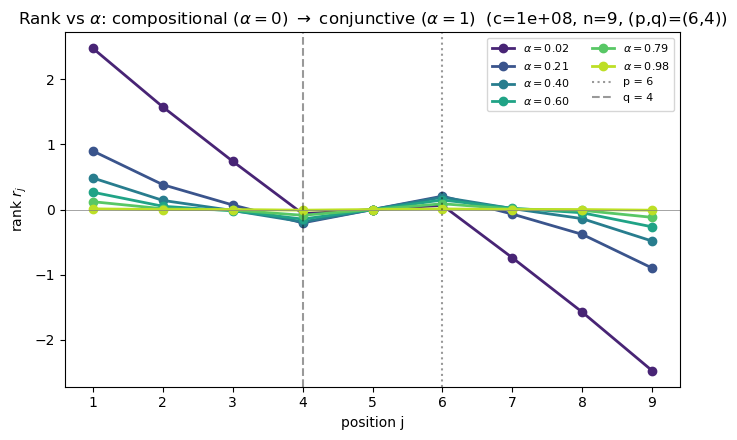

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ----------------------------------------------------
# Sweep alpha = 1 - 2*alpha_prime from 0 (compositional)
# to 1 (conjunctive) at a single c_reg
# ----------------------------------------------------
n, p, q    = 9, 6, 4
k_s, k_d   = 1.0, 0.0
c_reg      = 1e8                    # effectively no regularization

# 6 alphas in (0, 1). Avoid the exact endpoints:
#  - alpha = 0 <=> alpha_prime = 0.5  (formula's divide-by-zero)
#  - alpha = 1 <=> alpha_prime = 0    (kernel is just identity; fine but trivial)
alpha_vals = np.linspace(0.02, 0.98, 6)
alpha_prime_vals = (1 - alpha_vals) / 2

x = np.arange(1, n + 1)
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(alpha_vals)))

fig, ax = plt.subplots(figsize=(7, 4.5))
for a, ap, col in zip(alpha_vals, alpha_prime_vals, cmap):
    k_o = ap * (k_s - k_d)
    sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                      p=p, q=q, c_reg=c_reg)
    r = sim.calc_rank_analytic()
    ax.plot(x, r, marker='o', color=col, lw=2,
            label=fr'$\alpha={a:.2f}$')

ax.axvline(p, color='k', ls=':',  alpha=0.4, label=f'p = {p}')
ax.axvline(q, color='k', ls='--', alpha=0.4, label=f'q = {q}')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('position j')
ax.set_ylabel(r'rank $r_j$')
ax.set_title(fr'Rank vs $\alpha$: compositional ($\alpha=0$) $\rightarrow$ conjunctive ($\alpha=1$)  '
             fr'(c={c_reg:.0e}, n={n}, (p,q)=({p},{q}))')
ax.legend(loc='best', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
fig.savefig("figure_5a.pdf", bbox_inches="tight")

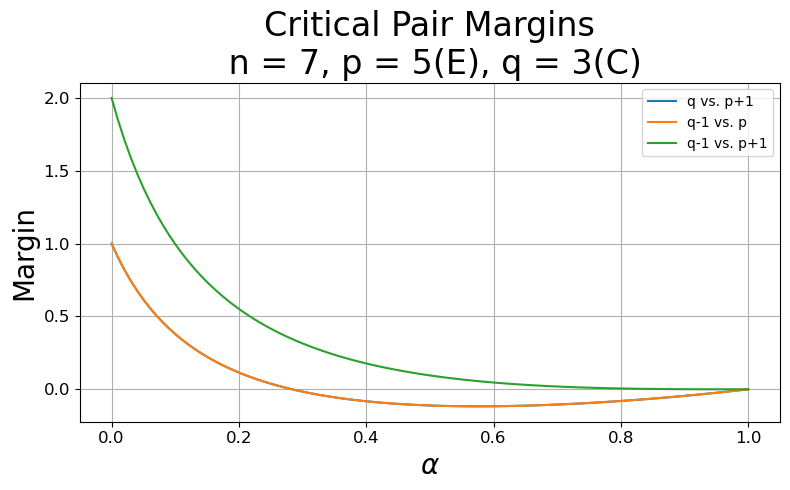

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---- hyperbolic helpers ----
def cosh(x):  return np.cosh(x)
def sinh(x):  return np.sinh(x)
def tanh(x):  return np.tanh(x)
def acosh(x): return np.arccosh(x)

# ---- global parameters (set by set_parameters) ----
n = p = q = None

def set_parameters(n_val, p_val, q_val):
    global n, p, q
    n, p, q = n_val, p_val, q_val

# ---- analytic rank / margin ----
def rank_original(j, k_o):
    alpha = 1 - 2 * k_o
    lamb  = acosh(1 / (1 - alpha))
    return sinh(((n + 1) / 2 - j) * lamb) / (
        sinh(((n + 1) / 2) * lamb) - sinh(((n - 1) / 2) * lamb)
    )

def get_c(k_o):
    alpha       = 1 - 2 * k_o
    lamb        = acosh(1 / (1 - alpha))
    alpha_prime = k_o
    num = 1 + (
        (sinh(((n + 1) / 2 - q) * lamb) - sinh(((n + 1) / 2 - p) * lamb))
        / (sinh(((n + 1) / 2) * lamb) - sinh(((n - 1) / 2) * lamb))
    )
    D_sim = (
        cosh((q - 0.5) * lamb) * sinh((n - ((p + q) / 2 - 0.5)) * lamb)
        + cosh((n - p + 0.5) * lamb) * sinh(((p + q) / 2 - 0.5) * lamb)
    )
    denom = (
        1 - 2 * alpha_prime
        - 4 * (1 / (2 * cosh(lamb)))
            * (tanh(lamb / 2) / sinh(lamb * n))
            * sinh(((q - p) / 2) * lamb)
            * D_sim
    )
    return num / denom

def D_ij_analytical_sol_trend3(i, j, k_o):
    alpha = 1 - 2 * k_o
    lamb  = acosh(1 / (1 - alpha))
    num   = 2 * cosh((min(i, j) - 0.5) * lamb) \
              * cosh((n - (max(i, j) - 0.5)) * lamb) \
              * tanh(lamb / 2)
    return num / sinh(lamb * n)

def rank_diff(j, k_o):
    alpha_prime = k_o
    return (
        get_c(k_o) * alpha_prime
        * (D_ij_analytical_sol_trend3(j, p, k_o)
           - D_ij_analytical_sol_trend3(j, q, k_o))
    )

def rank(j, k_o):
    return rank_original(j, k_o) + rank_diff(j, k_o)

def margin(j, k, k_o):
    return rank(j, k_o) - rank(k, k_o)

# ---- run the sweep ----
set_parameters(n_val=7, p_val=5, q_val=3)

k_o_array   = np.linspace(1e-11, 0.49999999, 100)
alpha_array = 1 - 2 * k_o_array

margin_A = np.array([margin(q,     p + 1, k_o) for k_o in k_o_array])  # q   vs p+1
margin_B = np.array([margin(q - 1, p,     k_o) for k_o in k_o_array])  # q-1 vs p
margin_C = np.array([margin(q - 1, p + 1, k_o) for k_o in k_o_array])  # q-1 vs p+1

# ---- plot ----
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_array, margin_A, label='q vs. p+1')
ax.plot(alpha_array, margin_B, label='q-1 vs. p')
ax.plot(alpha_array, margin_C, label='q-1 vs. p+1')
ax.legend()
ax.set_title(f'Critical Pair Margins\n n = {n}, p = {p}(E), q = {q}(C)',
             fontdict={'fontsize': 24, 'fontweight': 'medium'})
ax.set_xlabel(r'$\alpha$', fontdict={'fontsize': 20, 'fontweight': 'medium'})
ax.set_ylabel('Margin',    fontdict={'fontsize': 20, 'fontweight': 'medium'})
ax.grid(True)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.savefig("figure_5d.pdf")
plt.show()

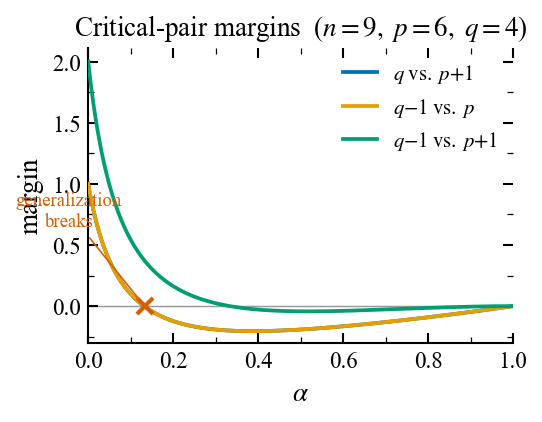

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ---- hyperbolic helpers ----
def cosh(x):  return np.cosh(x)
def sinh(x):  return np.sinh(x)
def tanh(x):  return np.tanh(x)
def acosh(x): return np.arccosh(x)

# ---- parameters ----
n, p, q = 9, 6, 4

# ---- analytic rank / margin ----
def rank_original(j, k_o):
    alpha = 1 - 2 * k_o
    lamb  = acosh(1 / (1 - alpha))
    return sinh(((n + 1) / 2 - j) * lamb) / (
        sinh(((n + 1) / 2) * lamb) - sinh(((n - 1) / 2) * lamb)
    )

def get_c(k_o):
    alpha       = 1 - 2 * k_o
    lamb        = acosh(1 / (1 - alpha))
    alpha_prime = k_o
    num = 1 + (
        (sinh(((n + 1) / 2 - q) * lamb) - sinh(((n + 1) / 2 - p) * lamb))
        / (sinh(((n + 1) / 2) * lamb) - sinh(((n - 1) / 2) * lamb))
    )
    D_sim = (
        cosh((q - 0.5) * lamb) * sinh((n - ((p + q) / 2 - 0.5)) * lamb)
        + cosh((n - p + 0.5) * lamb) * sinh(((p + q) / 2 - 0.5) * lamb)
    )
    denom = (
        1 - 2 * alpha_prime
        - 4 * (1 / (2 * cosh(lamb)))
            * (tanh(lamb / 2) / sinh(lamb * n))
            * sinh(((q - p) / 2) * lamb) * D_sim
    )
    return num / denom

def D_ij(i, j, k_o):
    alpha = 1 - 2 * k_o
    lamb  = acosh(1 / (1 - alpha))
    return (
        2 * cosh((min(i, j) - 0.5) * lamb)
          * cosh((n - (max(i, j) - 0.5)) * lamb)
          * tanh(lamb / 2)
        / sinh(lamb * n)
    )

def rank(j, k_o):
    return rank_original(j, k_o) + get_c(k_o) * k_o * (D_ij(j, p, k_o) - D_ij(j, q, k_o))

def margin(j, k, k_o):
    return rank(j, k_o) - rank(k, k_o)

# ---- sweep ----
k_o_array   = np.linspace(1e-11, 0.49999999, 400)
alpha_array = 1 - 2 * k_o_array

margin_A = np.array([margin(q,     p + 1, k_o) for k_o in k_o_array])
margin_B = np.array([margin(q - 1, p,     k_o) for k_o in k_o_array])
margin_C = np.array([margin(q - 1, p + 1, k_o) for k_o in k_o_array])

# find where margin_B crosses zero (generalization breaks)
sign_change = np.where(np.diff(np.sign(margin_B)))[0]
alpha_crit = alpha_array[sign_change[0]] if len(sign_change) else None

# ---- journal styling ----
plt.rcParams.update({
    'font.family':      'serif',
    'font.serif':       ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size':        11,
    'axes.labelsize':   13,
    'axes.titlesize':   13,
    'axes.linewidth':   1.0,
    'xtick.direction':  'in',
    'ytick.direction':  'in',
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'legend.frameon':    False,
    'legend.fontsize':   10,
    'savefig.dpi':       300,
    'figure.dpi':        150,
})

# colorblind-safe palette (Wong)
BLUE, ORANGE, GREEN, RED = '#0072B2', '#E69F00', '#009E73', '#D55E00'

fig, ax = plt.subplots(figsize=(3.5, 2.7), constrained_layout=True)   # single-column width

ax.axhline(0, color='0.6', lw=0.7, zorder=1)
ax.plot(alpha_array, margin_A, color=BLUE,   lw=1.8, label=r'$q \;\mathrm{vs.}\; p{+}1$', zorder=3)
ax.plot(alpha_array, margin_B, color=ORANGE, lw=1.8, label=r'$q{-}1 \;\mathrm{vs.}\; p$', zorder=3)
ax.plot(alpha_array, margin_C, color=GREEN,  lw=1.8, label=r'$q{-}1 \;\mathrm{vs.}\; p{+}1$', zorder=3)

# critical-alpha annotation
if alpha_crit is not None:
    ax.plot(alpha_crit, 0, marker='x', color=RED, ms=8, mew=2, zorder=4)
    ax.annotate(
        'generalization\nbreaks',
        xy=(alpha_crit, 0), xytext=(alpha_crit - 0.18, 0.65),
        fontsize=9, color=RED, ha='center',
        arrowprops=dict(arrowstyle='-', color=RED, lw=0.8),
    )

# axes
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('margin')
ax.set_xlim(0, 1)
ax.set_ylim(bottom=min(margin_B.min(), 0) - 0.1)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.25))

# clean spines
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_linewidth(1.0)

# title as a compact caption-style line
ax.set_title(fr'Critical-pair margins  ($n={n},\ p={p},\ q={q}$)', pad=6)

ax.legend(loc='upper right', handlelength=1.6, borderaxespad=0.3)

# plt.savefig('TI_critical_pairs_margins_n_7.pdf', bbox_inches='tight')
# plt.savefig('TI_critical_pairs_margins_n_7.svg', bbox_inches='tight')
plt.show()

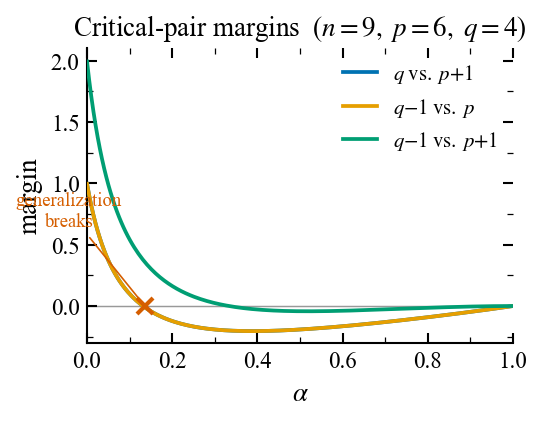

In [15]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from Ranking_exp import Ranking_exp

# ---- parameters ----
n, p, q    = 9, 6, 4
k_s, k_d   = 1.0, 0.0
c_reg      = 1e10          # effectively unregularized -> matches the alpha-only closed form

# ---- helper: make a Ranking_exp at a given k_o (quietly) ----
def make_sim(k_o):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=c_reg)

# ---- sweep ----
k_o_array   = np.linspace(1e-4, 0.4999, 200)     # avoid exact k_o = 0 or 0.5
alpha_array = 1 - 2 * k_o_array                  # alpha = 1 - 2 k_o

margin_A = np.zeros_like(k_o_array)   # q   vs p+1
margin_B = np.zeros_like(k_o_array)   # q-1 vs p
margin_C = np.zeros_like(k_o_array)   # q-1 vs p+1

for i, k_o in enumerate(k_o_array):
    sim = make_sim(k_o)
    margin_A[i] = sim.f_j_k(q,     p + 1)
    margin_B[i] = sim.f_j_k(q - 1, p)
    margin_C[i] = sim.f_j_k(q - 1, p + 1)

# critical alpha: first zero-crossing of margin_B
sign_change = np.where(np.diff(np.sign(margin_B)))[0]
alpha_crit  = alpha_array[sign_change[0]] if len(sign_change) else None

# ---- journal styling ----
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':  'stix',
    'font.size':         11,
    'axes.labelsize':    13,
    'axes.titlesize':    13,
    'axes.linewidth':    1.0,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  5,
    'ytick.major.size':  5,
    'xtick.minor.size':  3,
    'ytick.minor.size':  3,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'legend.frameon':    False,
    'legend.fontsize':   10,
    'savefig.dpi':       300,
    'figure.dpi':        150,
})

# Wong colorblind-safe palette
BLUE, ORANGE, GREEN, RED = '#0072B2', '#E69F00', '#009E73', '#D55E00'

fig, ax = plt.subplots(figsize=(3.5, 2.7), constrained_layout=True)

ax.axhline(0, color='0.6', lw=0.7, zorder=1)
ax.plot(alpha_array, margin_A, color=BLUE,   lw=1.8,
        label=r'$q \;\mathrm{vs.}\; p{+}1$',     zorder=3)
ax.plot(alpha_array, margin_B, color=ORANGE, lw=1.8,
        label=r'$q{-}1 \;\mathrm{vs.}\; p$',     zorder=3)
ax.plot(alpha_array, margin_C, color=GREEN,  lw=1.8,
        label=r'$q{-}1 \;\mathrm{vs.}\; p{+}1$', zorder=3)

# critical-alpha annotation
if alpha_crit is not None:
    ax.plot(alpha_crit, 0, marker='x', color=RED, ms=8, mew=2, zorder=4)
    ax.annotate(
        'generalization\nbreaks',
        xy=(alpha_crit, 0), xytext=(alpha_crit - 0.18, 0.65),
        fontsize=9, color=RED, ha='center',
        arrowprops=dict(arrowstyle='-', color=RED, lw=0.8),
    )

ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('margin')
ax.set_xlim(0, 1)
ax.set_ylim(bottom=min(margin_B.min(), 0) - 0.1)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.25))

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_linewidth(1.0)

ax.set_title(fr'Critical-pair margins  ($n={n},\ p={p},\ q={q}$)', pad=6)
ax.legend(loc='upper right', handlelength=1.6, borderaxespad=0.3)

# plt.savefig('figure_5_Ranking_exp.pdf', bbox_inches='tight')
plt.show()

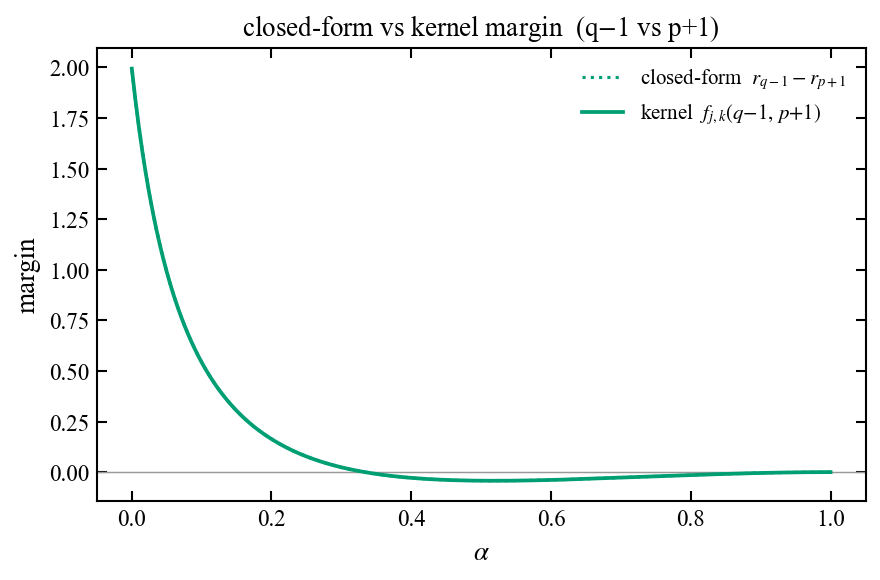

max |cf - kernel| over sweep: 9.104e-15
median |cf - kernel|      : 8.500e-17


In [19]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

n, p, q  = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg    = 1e10

def make_sim(k_o):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=c_reg)

k_o_array   = np.linspace(1e-4, 0.4999, 200)
alpha_array = 1 - 2 * k_o_array

margin_C_cf = np.zeros_like(k_o_array)
margin_C_kk = np.zeros_like(k_o_array)

for i, k_o in enumerate(k_o_array):
    sim = make_sim(k_o)
    r   = sim.calc_rank_analytic()
    margin_C_cf[i] = r[(q - 1) - 1] - r[(p + 1) - 1]    # (q-1, p+1) via r_i - r_j
    margin_C_kk[i] = sim.f_j_k(q - 1, p + 1)            # same pair via kernel prediction

fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(0, color='0.6', lw=0.7)
ax.plot(alpha_array, margin_C_cf, color='#009E73', lw=1.5, ls=':',
        label=r'closed-form  $r_{q-1} - r_{p+1}$')
ax.plot(alpha_array, margin_C_kk, color='#009E73', lw=1.8,
        label=r'kernel  $f_{j,k}(q{-}1,\,p{+}1)$')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('margin')
ax.set_title('closed-form vs kernel margin  (q$-$1 vs p+1)')
ax.legend()
plt.tight_layout()
plt.show()

diff = np.abs(margin_C_cf - margin_C_kk)
print(f'max |cf - kernel| over sweep: {diff.max():.3e}')
print(f'median |cf - kernel|      : {np.median(diff):.3e}')

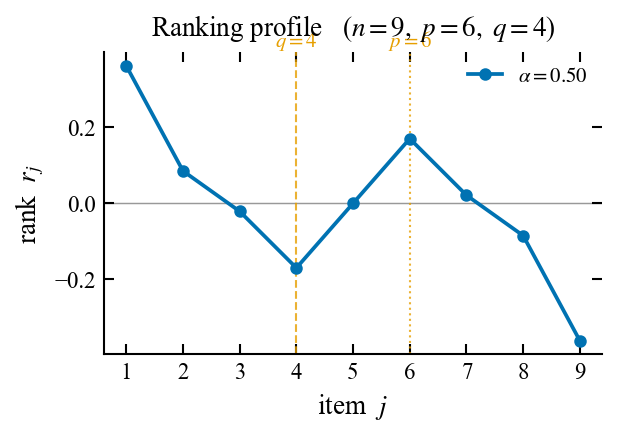

In [20]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

n, p, q  = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg    = 1e10                 # unregularized
alpha_prime = 0.25              # pick a single representative alpha_prime

def make_sim(k_o):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=c_reg)

k_o = alpha_prime * (k_s - k_d)
sim = make_sim(k_o)
r   = sim.calc_rank_analytic()
alpha_val = 1 - 2 * alpha_prime

# ---- journal styling ----
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':  'stix',
    'font.size':         11,
    'axes.labelsize':    13,
    'axes.titlesize':    13,
    'axes.linewidth':    1.0,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  5,
    'ytick.major.size':  5,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'legend.frameon':    False,
    'legend.fontsize':   10,
    'savefig.dpi':       300,
    'figure.dpi':        150,
})

BLUE, ORANGE, RED = '#0072B2', '#E69F00', '#D55E00'

x = np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(4.0, 2.8), constrained_layout=True)
ax.axhline(0, color='0.6', lw=0.7, zorder=1)

# highlight the exception pair with vertical ticks
ax.axvline(p, color=ORANGE, ls=':',  lw=1.0, alpha=0.8, zorder=2)
ax.axvline(q, color=ORANGE, ls='--', lw=1.0, alpha=0.8, zorder=2)

ax.plot(x, r, color=BLUE, lw=1.8, marker='o', ms=5, zorder=3,
        label=fr'$\alpha={alpha_val:.2f}$')

# annotate p / q
ax.text(p, ax.get_ylim()[1], fr'$p={p}$', ha='center', va='bottom',
        fontsize=10, color=ORANGE)
ax.text(q, ax.get_ylim()[1], fr'$q={q}$', ha='center', va='bottom',
        fontsize=10, color=ORANGE)

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

ax.set_xlabel('item  $j$')
ax.set_ylabel(r'rank  $r_j$')
ax.set_xticks(x)
ax.set_title(fr'Ranking profile   ($n={n},\ p={p},\ q={q}$)', pad=8)
ax.legend(loc='upper right', handlelength=1.6, borderaxespad=0.3)

# plt.savefig('figure_5_ranks.pdf', bbox_inches='tight')
plt.show()

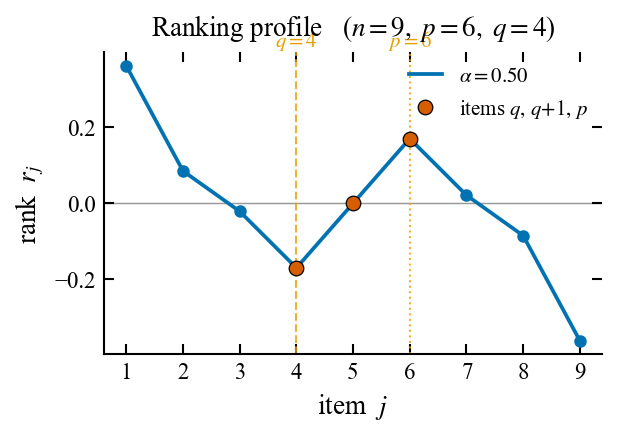

In [21]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

n, p, q  = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg    = 1e10
alpha_prime = 0.25

def make_sim(k_o):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=c_reg)

k_o = alpha_prime * (k_s - k_d)
r   = make_sim(k_o).calc_rank_analytic()
alpha_val = 1 - 2 * alpha_prime

plt.rcParams.update({
    'font.family':'serif', 'font.serif':['Times New Roman','DejaVu Serif'],
    'mathtext.fontset':'stix', 'font.size':11,
    'axes.labelsize':13, 'axes.titlesize':13, 'axes.linewidth':1.0,
    'xtick.direction':'in', 'ytick.direction':'in',
    'xtick.major.size':5, 'ytick.major.size':5,
    'xtick.major.width':1.0, 'ytick.major.width':1.0,
    'legend.frameon':False, 'legend.fontsize':10,
    'savefig.dpi':300, 'figure.dpi':150,
})

BLUE, ORANGE, RED = '#0072B2', '#E69F00', '#D55E00'

x         = np.arange(1, n + 1)
highlight = np.array([4, 5, 6])
mask_hi   = np.isin(x, highlight)

fig, ax = plt.subplots(figsize=(4.0, 2.8), constrained_layout=True)
ax.axhline(0, color='0.6', lw=0.7, zorder=1)
ax.axvline(p, color=ORANGE, ls=':',  lw=1.0, alpha=0.8, zorder=2)
ax.axvline(q, color=ORANGE, ls='--', lw=1.0, alpha=0.8, zorder=2)

ax.plot(x, r, color=BLUE, lw=1.8, zorder=3,
        label=fr'$\alpha={alpha_val:.2f}$')
ax.plot(x[~mask_hi], r[~mask_hi],
        marker='o', ms=5, linestyle='', color=BLUE, zorder=4)
ax.plot(x[mask_hi], r[mask_hi],
        marker='o', ms=7, linestyle='', color=RED,
        markeredgecolor='black', markeredgewidth=0.6, zorder=5,
        label=r'items $q,\,q{+}1,\,p$')

ax.text(p, ax.get_ylim()[1], fr'$p={p}$', ha='center', va='bottom',
        fontsize=10, color=ORANGE)
ax.text(q, ax.get_ylim()[1], fr'$q={q}$', ha='center', va='bottom',
        fontsize=10, color=ORANGE)

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

ax.set_xlabel('item  $j$')
ax.set_ylabel(r'rank  $r_j$')
ax.set_xticks(x)
ax.set_title(fr'Ranking profile   ($n={n},\ p={p},\ q={q}$)', pad=8)
ax.legend(loc='upper right', handlelength=1.6, borderaxespad=0.3)
plt.show()

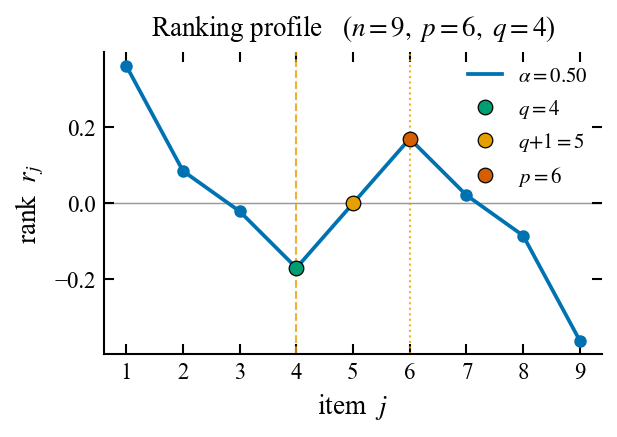

In [22]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

n, p, q  = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg    = 1e10
alpha_prime = 0.25

def make_sim(k_o):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=c_reg)

k_o = alpha_prime * (k_s - k_d)
r   = make_sim(k_o).calc_rank_analytic()
alpha_val = 1 - 2 * alpha_prime

plt.rcParams.update({
    'font.family':'serif', 'font.serif':['Times New Roman','DejaVu Serif'],
    'mathtext.fontset':'stix', 'font.size':11,
    'axes.labelsize':13, 'axes.titlesize':13, 'axes.linewidth':1.0,
    'xtick.direction':'in', 'ytick.direction':'in',
    'xtick.major.size':5, 'ytick.major.size':5,
    'xtick.major.width':1.0, 'ytick.major.width':1.0,
    'legend.frameon':False, 'legend.fontsize':10,
    'savefig.dpi':300, 'figure.dpi':150,
})

BLUE, ORANGE = '#0072B2', '#E69F00'
HIGHLIGHT = {4: ('#009E73', r'$q=4$'),
             5: ('#E69F00', r'$q{+}1=5$'),
             6: ('#D55E00', r'$p=6$')}

x       = np.arange(1, n + 1)
mask_hi = np.isin(x, list(HIGHLIGHT.keys()))

fig, ax = plt.subplots(figsize=(4.0, 2.8), constrained_layout=True)
ax.axhline(0, color='0.6', lw=0.7, zorder=1)
ax.axvline(p, color=ORANGE, ls=':',  lw=1.0, alpha=0.8, zorder=2)
ax.axvline(q, color=ORANGE, ls='--', lw=1.0, alpha=0.8, zorder=2)

ax.plot(x, r, color=BLUE, lw=1.8, zorder=3,
        label=fr'$\alpha={alpha_val:.2f}$')
ax.plot(x[~mask_hi], r[~mask_hi],
        marker='o', ms=5, linestyle='', color=BLUE, zorder=4)

for xi, (color, lbl) in HIGHLIGHT.items():
    ax.plot(xi, r[xi - 1], marker='o', ms=7, linestyle='',
            color=color, markeredgecolor='black', markeredgewidth=0.6,
            zorder=5, label=lbl)

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

ax.set_xlabel('item  $j$')
ax.set_ylabel(r'rank  $r_j$')
ax.set_xticks(x)
ax.set_title(fr'Ranking profile   ($n={n},\ p={p},\ q={q}$)', pad=8)
ax.legend(loc='upper right', handlelength=1.6, borderaxespad=0.3, ncol=1)
plt.show()

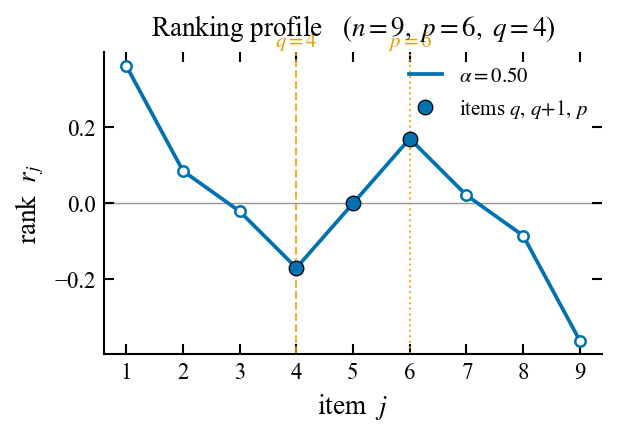

In [23]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

n, p, q  = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg    = 1e10
alpha_prime = 0.25

def make_sim(k_o):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=c_reg)

k_o = alpha_prime * (k_s - k_d)
r   = make_sim(k_o).calc_rank_analytic()
alpha_val = 1 - 2 * alpha_prime

plt.rcParams.update({
    'font.family':'serif', 'font.serif':['Times New Roman','DejaVu Serif'],
    'mathtext.fontset':'stix', 'font.size':11,
    'axes.labelsize':13, 'axes.titlesize':13, 'axes.linewidth':1.0,
    'xtick.direction':'in', 'ytick.direction':'in',
    'xtick.major.size':5, 'ytick.major.size':5,
    'xtick.major.width':1.0, 'ytick.major.width':1.0,
    'legend.frameon':False, 'legend.fontsize':10,
    'savefig.dpi':300, 'figure.dpi':150,
})

BLUE, ORANGE = '#0072B2', '#E69F00'

x         = np.arange(1, n + 1)
highlight = np.array([4, 5, 6])
mask_hi   = np.isin(x, highlight)

fig, ax = plt.subplots(figsize=(4.0, 2.8), constrained_layout=True)
ax.axhline(0, color='0.6', lw=0.7, zorder=1)
ax.axvline(p, color=ORANGE, ls=':',  lw=1.0, alpha=0.8, zorder=2)
ax.axvline(q, color=ORANGE, ls='--', lw=1.0, alpha=0.8, zorder=2)

ax.plot(x, r, color=BLUE, lw=1.8, zorder=3,
        label=fr'$\alpha={alpha_val:.2f}$')
ax.plot(x[~mask_hi], r[~mask_hi],
        marker='o', ms=5, linestyle='',
        markerfacecolor='white', markeredgecolor=BLUE, markeredgewidth=1.2,
        zorder=4)
ax.plot(x[mask_hi], r[mask_hi],
        marker='o', ms=7, linestyle='', color=BLUE,
        markeredgecolor='black', markeredgewidth=0.6, zorder=5,
        label=r'items $q,\,q{+}1,\,p$')

ax.text(p, ax.get_ylim()[1], fr'$p={p}$', ha='center', va='bottom',
        fontsize=10, color=ORANGE)
ax.text(q, ax.get_ylim()[1], fr'$q={q}$', ha='center', va='bottom',
        fontsize=10, color=ORANGE)

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

ax.set_xlabel('item  $j$')
ax.set_ylabel(r'rank  $r_j$')
ax.set_xticks(x)
ax.set_title(fr'Ranking profile   ($n={n},\ p={p},\ q={q}$)', pad=8)
ax.legend(loc='upper right', handlelength=1.6, borderaxespad=0.3)
plt.show()

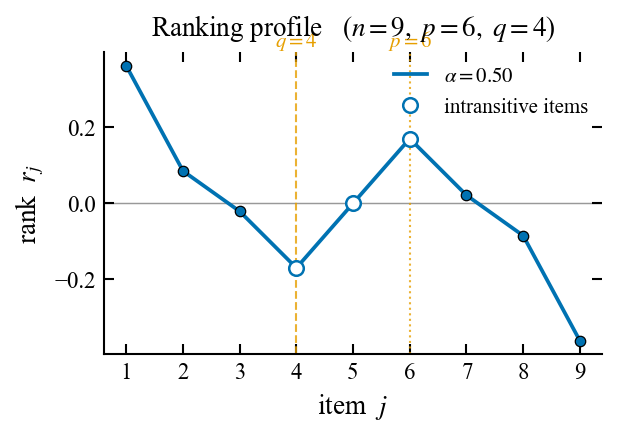

In [ ]:
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

n, p, q  = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg    = 1e10
alpha_prime = 0.25

def make_sim(k_o):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=c_reg)

k_o = alpha_prime * (k_s - k_d)
r   = make_sim(k_o).calc_rank_analytic()
alpha_val = 1 - 2 * alpha_prime

plt.rcParams.update({
    'font.family':'serif', 'font.serif':['Times New Roman','DejaVu Serif'],
    'mathtext.fontset':'stix', 'font.size':11,
    'axes.labelsize':13, 'axes.titlesize':13, 'axes.linewidth':1.0,
    'xtick.direction':'in', 'ytick.direction':'in',
    'xtick.major.size':5, 'ytick.major.size':5,
    'xtick.major.width':1.0, 'ytick.major.width':1.0,
    'legend.frameon':False, 'legend.fontsize':10,
    'savefig.dpi':300, 'figure.dpi':150,
})

BLUE, ORANGE = '#0072B2', '#E69F00'

x         = np.arange(1, n + 1)
highlight = np.array([4, 5, 6])
mask_hi   = np.isin(x, highlight)

fig, ax = plt.subplots(figsize=(4.0, 2.8), constrained_layout=True)
ax.axhline(0, color='0.6', lw=0.7, zorder=1)
ax.axvline(p, color=ORANGE, ls=':',  lw=1.0, alpha=0.8, zorder=2)
ax.axvline(q, color=ORANGE, ls='--', lw=1.0, alpha=0.8, zorder=2)

ax.plot(x, r, color=BLUE, lw=1.8, zorder=3,
        label=fr'$\alpha={alpha_val:.2f}$')

# filled markers for the non-highlighted items
ax.plot(x[~mask_hi], r[~mask_hi],
        marker='o', ms=5, linestyle='', color=BLUE,
        markeredgecolor='black', markeredgewidth=0.6,
        zorder=4)

# open circles for items 4, 5, 6
ax.plot(x[mask_hi], r[mask_hi],
        marker='o', ms=7, linestyle='',
        markerfacecolor='white', markeredgecolor=BLUE, markeredgewidth=1.2,
        zorder=5,
        label=r'transitive ')

ax.text(p, ax.get_ylim()[1], fr'$p={p}$', ha='center', va='bottom',
        fontsize=10, color=ORANGE)
ax.text(q, ax.get_ylim()[1], fr'$q={q}$', ha='center', va='bottom',
        fontsize=10, color=ORANGE)

for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

ax.set_xlabel('item  $j$')
ax.set_ylabel(r'rank  $r_j$')
ax.set_xticks(x)
ax.set_title(fr'Ranking profile   ($n={n},\ p={p},\ q={q}$)', pad=8)
ax.legend(loc='upper right', handlelength=1.6, borderaxespad=0.3)
plt.show()

In [17]:
margin_A_cf = np.zeros_like(k_o_array)
margin_A_kk = np.zeros_like(k_o_array)

for i, k_o in enumerate(k_o_array):
    sim = make_sim(k_o)
    r   = sim.calc_rank_analytic()
    margin_A_cf[i] = r[q - 1] - r[p + 1 - 1]     # (q)   vs (p+1)  via r_i - r_j
    margin_A_kk[i] = sim.f_j_k(q, p + 1)         # same pair via kernel prediction

ax.plot(alpha_array, margin_A_cf, color=BLUE, lw=1.5, ls=':',
        label='closed-form q vs p+1')
ax.plot(alpha_array, margin_A_kk, color=BLUE, lw=1.8,
        label=r'$f_{j,k}$ q vs p+1')

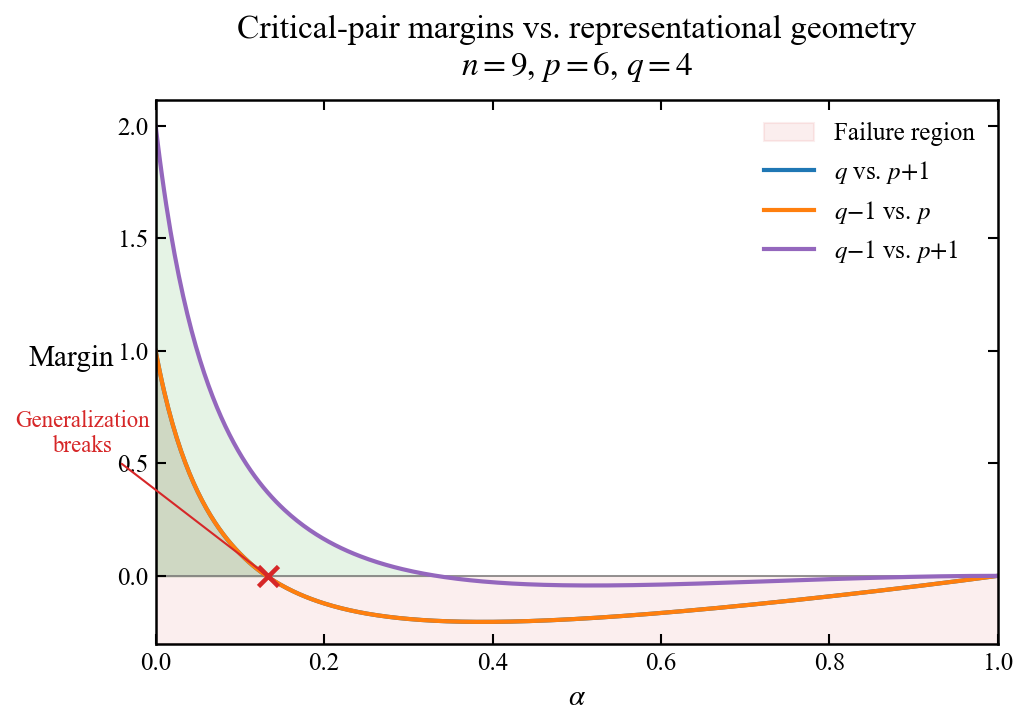

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ---- hyperbolic helpers ----
def cosh(x):  return np.cosh(x)
def sinh(x):  return np.sinh(x)
def tanh(x):  return np.tanh(x)
def acosh(x): return np.arccosh(x)

# ---- parameters ----
n, p, q = 9, 6, 4

# ---- analytic rank / margin ----
def rank_original(j, k_o):
    alpha = 1 - 2 * k_o
    lamb  = acosh(1 / (1 - alpha))
    return sinh(((n + 1) / 2 - j) * lamb) / (
        sinh(((n + 1) / 2) * lamb) - sinh(((n - 1) / 2) * lamb)
    )

def get_c(k_o):
    alpha       = 1 - 2 * k_o
    lamb        = acosh(1 / (1 - alpha))
    alpha_prime = k_o
    num = 1 + (
        (sinh(((n + 1) / 2 - q) * lamb) - sinh(((n + 1) / 2 - p) * lamb))
        / (sinh(((n + 1) / 2) * lamb) - sinh(((n - 1) / 2) * lamb))
    )
    D_sim = (
        cosh((q - 0.5) * lamb) * sinh((n - ((p + q) / 2 - 0.5)) * lamb)
        + cosh((n - p + 0.5) * lamb) * sinh(((p + q) / 2 - 0.5) * lamb)
    )
    denom = (
        1 - 2 * alpha_prime
        - 4 * (1 / (2 * cosh(lamb)))
            * (tanh(lamb / 2) / sinh(lamb * n))
            * sinh(((q - p) / 2) * lamb) * D_sim
    )
    return num / denom

def D_ij(i, j, k_o):
    alpha = 1 - 2 * k_o
    lamb  = acosh(1 / (1 - alpha))
    return (
        2 * cosh((min(i, j) - 0.5) * lamb)
          * cosh((n - (max(i, j) - 0.5)) * lamb)
          * tanh(lamb / 2)
        / sinh(lamb * n)
    )

def rank(j, k_o):
    return rank_original(j, k_o) + get_c(k_o) * k_o * (D_ij(j, p, k_o) - D_ij(j, q, k_o))

def margin(j, k, k_o):
    return rank(j, k_o) - rank(k, k_o)

# ---- sweep ----
k_o_array   = np.linspace(1e-11, 0.49999999, 400)
alpha_array = 1 - 2 * k_o_array

margin_A = np.array([margin(q,     p + 1, k_o) for k_o in k_o_array])  # q   vs p+1
margin_B = np.array([margin(q - 1, p,     k_o) for k_o in k_o_array])  # q-1 vs p
margin_C = np.array([margin(q - 1, p + 1, k_o) for k_o in k_o_array])  # q-1 vs p+1

y_lo, y_hi = ax.get_ylim()   # call this after set_ylim(...) below
if alpha_crit is not None:
    ax.axvspan(0,          alpha_crit, color=GREEN, alpha=0.08, zorder=0)
    ax.axvspan(alpha_crit, 1,          color=RED,   alpha=0.08, zorder=0)
    ax.axvline(alpha_crit, color='0.3', lw=1.0, ls='--', zorder=1)
    # small label on the top axis
    ax.text(alpha_crit, ax.get_ylim()[1], r'$\alpha^{*}$',
            ha='center', va='bottom', fontsize=13, color='0.2')

# ---- global style (matches phase_diagram.ipynb) ----
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman'],
    'mathtext.fontset':  'stix',
    'font.size':         12,
    'axes.linewidth':    1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
})

# palette matching the phase-diagram figure
BLUE, ORANGE, PURPLE = '#1f77b4', '#ff7f0e', '#9467bd'
RED = '#d62728'

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

ax.axhspan(min(margin_B.min(), 0) - 0.1, 0, color=RED, alpha=0.08, zorder=0,
           label='Failure region')

# subtle fills so the curves read like shaded regions
ax.fill_between(alpha_array, 0, margin_A, where=(margin_A > 0),
                alpha=0.12, color=BLUE)
ax.fill_between(alpha_array, 0, margin_B, where=(margin_B > 0),
                alpha=0.12, color=ORANGE)
ax.fill_between(alpha_array, 0, margin_C, where=(margin_C > 0),
                alpha=0.12, color=GREEN)

# curves on top
ax.plot(alpha_array, margin_A, linewidth=2, color=BLUE,
        label=r'$q$ vs. $p{+}1$')
ax.plot(alpha_array, margin_B, linewidth=2, color=ORANGE,
        label=r'$q{-}1$ vs. $p$')
ax.plot(alpha_array, margin_C, linewidth=2, color=PURPLE,
        label=r'$q{-}1$ vs. $p{+}1$')

# zero reference
ax.axhline(0, color='0.5', linewidth=0.8, zorder=1)

# generalization-breaking marker
if alpha_crit is not None:
    ax.plot(alpha_crit, 0, marker='x', color=RED, ms=10, mew=2.2, zorder=5)
    ax.annotate(
        'Generalization\nbreaks',
        xy=(alpha_crit, 0), xytext=(alpha_crit - 0.22, 0.55),
        color=RED, fontsize=11, ha='center',
        arrowprops=dict(arrowstyle='-', color=RED, lw=1.0),
    )

# labels
ax.set_xlabel(r'$\alpha$', fontsize=14)
ax.set_ylabel('Margin', fontsize=14, rotation=0, labelpad=22)
ax.set_title(
    f'Critical-pair margins vs. representational geometry\n'
    f'$n={n}$, $p={p}$, $q={q}$',
    fontsize=16, pad=12,
)

ax.legend(fontsize=12, framealpha=0.9, edgecolor='gray',
          loc='upper right')

ax.set_xlim(0, 1)
ax.set_ylim(bottom=min(margin_B.min(), 0) - 0.1)
ax.grid(False)

fig.tight_layout()
plt.savefig('figure_5d_nice.pdf', bbox_inches='tight')
# plt.savefig('TI_critical_pairs_margins_n_7.svg', bbox_inches='tight')
plt.show()

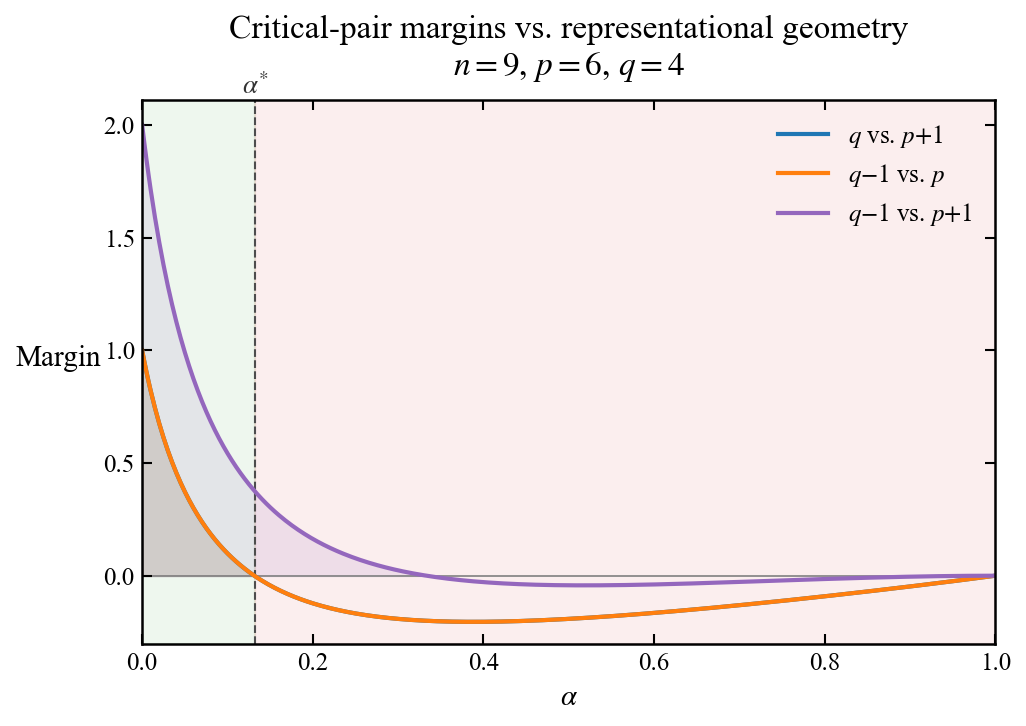

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ---- hyperbolic helpers ----
def cosh(x):  return np.cosh(x)
def sinh(x):  return np.sinh(x)
def tanh(x):  return np.tanh(x)
def acosh(x): return np.arccosh(x)

# ---- parameters ----
n, p, q = 9, 6, 4

# ---- analytic rank / margin ----
def rank_original(j, k_o):
    alpha = 1 - 2 * k_o
    lamb  = acosh(1 / (1 - alpha))
    return sinh(((n + 1) / 2 - j) * lamb) / (
        sinh(((n + 1) / 2) * lamb) - sinh(((n - 1) / 2) * lamb)
    )

def get_c(k_o):
    alpha       = 1 - 2 * k_o
    lamb        = acosh(1 / (1 - alpha))
    alpha_prime = k_o
    num = 1 + (
        (sinh(((n + 1) / 2 - q) * lamb) - sinh(((n + 1) / 2 - p) * lamb))
        / (sinh(((n + 1) / 2) * lamb) - sinh(((n - 1) / 2) * lamb))
    )
    D_sim = (
        cosh((q - 0.5) * lamb) * sinh((n - ((p + q) / 2 - 0.5)) * lamb)
        + cosh((n - p + 0.5) * lamb) * sinh(((p + q) / 2 - 0.5) * lamb)
    )
    denom = (
        1 - 2 * alpha_prime
        - 4 * (1 / (2 * cosh(lamb)))
            * (tanh(lamb / 2) / sinh(lamb * n))
            * sinh(((q - p) / 2) * lamb) * D_sim
    )
    return num / denom

def D_ij(i, j, k_o):
    alpha = 1 - 2 * k_o
    lamb  = acosh(1 / (1 - alpha))
    return (
        2 * cosh((min(i, j) - 0.5) * lamb)
          * cosh((n - (max(i, j) - 0.5)) * lamb)
          * tanh(lamb / 2)
        / sinh(lamb * n)
    )

def rank(j, k_o):
    return rank_original(j, k_o) + get_c(k_o) * k_o * (D_ij(j, p, k_o) - D_ij(j, q, k_o))

def margin(j, k, k_o):
    return rank(j, k_o) - rank(k, k_o)

# ---- sweep ----
k_o_array   = np.linspace(1e-11, 0.49999999, 400)
alpha_array = 1 - 2 * k_o_array

margin_A = np.array([margin(q,     p + 1, k_o) for k_o in k_o_array])  # q   vs p+1
margin_B = np.array([margin(q - 1, p,     k_o) for k_o in k_o_array])  # q-1 vs p
margin_C = np.array([margin(q - 1, p + 1, k_o) for k_o in k_o_array])  # q-1 vs p+1

# critical alpha: first zero-crossing of margin_B
sign_change = np.where(np.diff(np.sign(margin_B)))[0]
alpha_crit  = alpha_array[sign_change[0]] if len(sign_change) else None

# ---- global style (matches phase_diagram.ipynb) ----
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman'],
    'mathtext.fontset':  'stix',
    'font.size':         12,
    'axes.linewidth':    1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
})

# palette
BLUE, ORANGE, PURPLE = '#1f77b4', '#ff7f0e', '#9467bd'
GREEN, RED           = '#2ca02c', '#d62728'

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)

# subtle positive-margin fills under each curve
ax.fill_between(alpha_array, 0, margin_A, where=(margin_A > 0),
                alpha=0.12, color=BLUE)
ax.fill_between(alpha_array, 0, margin_B, where=(margin_B > 0),
                alpha=0.12, color=ORANGE)
ax.fill_between(alpha_array, 0, margin_C, where=(margin_C > 0),
                alpha=0.12, color=PURPLE)

# curves on top
ax.plot(alpha_array, margin_A, linewidth=2, color=BLUE,
        label=r'$q$ vs. $p{+}1$')
ax.plot(alpha_array, margin_B, linewidth=2, color=ORANGE,
        label=r'$q{-}1$ vs. $p$')
ax.plot(alpha_array, margin_C, linewidth=2, color=PURPLE,
        label=r'$q{-}1$ vs. $p{+}1$')

# zero reference
ax.axhline(0, color='0.5', linewidth=0.8, zorder=1)

# labels
ax.set_xlabel(r'$\alpha$', fontsize=14)
ax.set_ylabel('Margin', fontsize=14, rotation=0, labelpad=22)
ax.set_title(
    f'Critical-pair margins vs. representational geometry\n'
    f'$n={n}$, $p={p}$, $q={q}$',
    fontsize=16, pad=12,
)

ax.set_xlim(0, 1)
ax.set_ylim(bottom=min(margin_B.min(), 0) - 0.1)
ax.grid(False)

# ---- split the plot into "generalizes" / "fails" regions at alpha* ----
if alpha_crit is not None:
    ax.axvspan(0,          alpha_crit, color=GREEN, alpha=0.08, zorder=0)
    ax.axvspan(alpha_crit, 1,          color=RED,   alpha=0.08, zorder=0)
    ax.axvline(alpha_crit, color='0.3', lw=1.0, ls='--', zorder=1)
    ax.text(alpha_crit, ax.get_ylim()[1], r'$\alpha^{*}$',
            ha='center', va='bottom', fontsize=13, color='0.2')

ax.legend(fontsize=12, framealpha=0.9, edgecolor='gray',
          loc='upper right')

fig.tight_layout()
plt.savefig('figure_5d_nice.pdf', bbox_inches='tight')
# plt.savefig('TI_critical_pairs_margins_n_7.svg', bbox_inches='tight')
plt.show()
